## AUC Scatter and Chapter Boxplots
###
### This notebook draws per-token AUC scatter plots and chapter-wise AUC boxplots

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D

# Resolve paths robustly whether the notebook is run from repo root or figure/.
CWD = Path.cwd()
FIGURE_DIR = CWD if (CWD / 'figutils').exists() else CWD / 'figure'
REPO_DIR = FIGURE_DIR.parent

RESULTS_BASE = REPO_DIR / 'results' / '0506'
LABELS_CANDIDATES = [
    REPO_DIR.parent / 'data' / 'labels_chapter.csv',
    REPO_DIR / 'data' / 'labels_chapter.csv',
    FIGURE_DIR.parent.parent / 'data' / 'labels_chapter.csv',
]
LABELS_PATH = next((p for p in LABELS_CANDIDATES if p.exists()), None)
if LABELS_PATH is None:
    raise FileNotFoundError('Could not find labels_chapter.csv')

font_path = FIGURE_DIR / 'figutils' / 'Helvetica.ttf'
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = fm.FontProperties(fname=str(font_path)).get_name()

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams.update({
    'axes.grid': True,
    'grid.linestyle': ':',
    'axes.spines.bottom': False,
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
})

# Same color remapping used in figure/umap.ipynb.
COLOR_REMAP = {
    '#98df8a': '#91c987',  # I. Infectious Diseases
    '#ff7f0e': '#ec713f',  # II. Neoplasms
    '#ff9896': '#dd5752',  # III. Blood & Immune Disorders
    '#2ca02c': '#4f7951',  # IV. Metabolic Diseases
    '#9edae5': '#90c0c2',  # V. Mental Disorders
    '#7f7f7f': '#87776a',  # VI/VII. Nervous / Eye Diseases
    '#dbdb8d': '#e6c186',  # VIII. Ear Diseases
    '#d62728': '#c34a54',  # IX. Circulatory Diseases
    '#17becf': '#567797',  # X. Respiratory Diseases
    '#8c564b': '#6b512a',  # XI. Digestive Diseases
    '#1f77b4': '#2964b8',  # XIII. Musculoskeletal Diseases
    '#ffbb78': '#f7b141',  # XIV. Genitourinary Diseases
    '#e377c2': '#e45c88',  # XV/XVII. Pregnancy / Congenital
    '#FFFF00': '#E7C547',  # Diabetes Drugs
    '#000a35': '#1d1f20',  # Death
}

DATASET_CFG = {
    'KR':      {'subdir': 'KR_rerun',      'prefix': 'val',        'title': 'KR'},
    'KR_full': {'subdir': 'KR_rerun_full', 'prefix': 'val',        'title': 'KR'},
    'JMDC':    {'subdir': 'JMDC',          'prefix': 'jmdc',       'title': 'JMDC'},
    'UKB':     {'subdir': 'UKB_rerun',     'prefix': 'extval_ukb', 'title': 'UKB'},
    'CKB':     {'subdir': 'CKB',           'prefix': 'extval_ckb', 'title': 'CKB'},
}

ICD_CHAPTER_ORDER = [
    'I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X',
    'XI', 'XII', 'XIII', 'XIV', 'XV', 'XVI', 'XVII', 'Diabetes Drugs', 'Death'
]
CHAPTER_LEGEND_LABELS = {
    'I': 'I: Infectious Diseases',
    'II': 'II: Neoplasms',
    'III': 'III: Blood & Immune Disorders',
    'IV': 'IV: Metabolic Diseases',
    'V': 'V: Mental Disorders',
    'VI': 'VI: Nervous System Diseases',
    'VII': 'VII: Eye Diseases',
    'VIII': 'VIII: Ear Diseases',
    'IX': 'IX: Circulatory Diseases',
    'X': 'X: Respiratory Diseases',
    'XI': 'XI: Digestive Diseases',
    'XII': 'XII: Skin Diseases',
    'XIII': 'XIII: Musculoskeletal Diseases',
    'XIV': 'XIV: Genitourinary Diseases',
    'XV': 'XV: Pregnancy & Childbirth',
    'XVI': 'XVI: Perinatal Conditions',
    'XVII': 'XVII: Congenital Abnormalities',
    'Diabetes Drugs': 'Diabetes Drugs',
    'Death': 'Death',
}

DATASET = 'KR_full'  # one of: KR | KR_full | JMDC | UKB | CKB
INCLUDE_DEATH = True
SAVE_FIGURES = False
SHOW_CHAPTER_LEGEND = False
CHAPTER_LEGEND_INCLUDE_DEATH = True
OUTPUT_DIR = FIGURE_DIR / 'out'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'labels: {LABELS_PATH}')
print(f'results: {RESULTS_BASE}')

labels: /home/hsh/hsh/data/labels_chapter.csv
results: /home/hsh/hsh/GPT-Disease-Drug-Prediction/results/0506


In [ ]:
def load_chapter_metadata(labels_path=LABELS_PATH):
    labels = pd.read_csv(labels_path)
    labels.columns = ['name', 'token_id', 'chapter_full', 'chapter_short', 'color']
    labels['token_id'] = pd.to_numeric(labels['token_id'], errors='coerce')
    labels = labels.dropna(subset=['token_id']).copy()
    labels['token_id'] = labels['token_id'].astype(int)
    labels['color'] = labels['color'].replace(COLOR_REMAP)
    labels['chapter_full'] = labels['chapter_full'].replace({'XX. Diabetes drugs': 'Diabetes Drugs'})
    labels['chapter_short'] = labels['chapter_short'].replace({'XX. Diabetes drugs': 'Diabetes Drugs'})
    labels['chapter_code'] = labels['chapter_short'].where(
        labels['chapter_short'].eq('Diabetes Drugs'),
        labels['chapter_short'].str.split('.').str[0].str.strip(),
    )

    # Keep disease chapters in their source order; optionally keep Death as its own group.
    excluded = {'Technical', 'Sex', 'Smoking, Alcohol and BMI'}
    if not INCLUDE_DEATH:
        excluded.add('Death')
    labels = labels[~labels['chapter_short'].isin(excluded)].copy()

    chapter_order = [ch for ch in ICD_CHAPTER_ORDER if ch in set(labels['chapter_code'])]
    chapter_palette = (
        labels[['chapter_code', 'color']]
        .drop_duplicates('chapter_code')
        .set_index('chapter_code')['color']
        .to_dict()
    )
    return labels[['token_id', 'name', 'chapter_full', 'chapter_short', 'chapter_code', 'color']], chapter_order, chapter_palette


def _pick_auc_col(df):
    if 'auc_delong' in df.columns and pd.to_numeric(df['auc_delong'], errors='coerce').notna().any():
        return 'auc_delong'
    if 'auc' in df.columns:
        return 'auc'
    raise ValueError('Could not find an AUC column.')


def _pick_occurrence_col(df):
    for col in ('n_diseased', 'n_cases', 'n_target_tokens', 'n_samples'):
        if col in df.columns:
            return col
    raise ValueError('Could not find an occurrence/count column.')


def load_auc_dataset(dataset=DATASET):
    cfg = DATASET_CFG[dataset]
    result_dir = RESULTS_BASE / cfg['subdir']
    csv_path = result_dir / f"{cfg['prefix']}_df_both.csv"
    if not csv_path.exists():
        raise FileNotFoundError(csv_path)

    meta, chapter_order, chapter_palette = load_chapter_metadata()
    df = pd.read_csv(csv_path)
    if 'status' in df.columns:
        df = df[df['status'] == 'ok'].copy()
    if 'sex' in df.columns:
        df = df[df['sex'].fillna('all').eq('all')].copy()

    auc_col = _pick_auc_col(df)
    occ_col = _pick_occurrence_col(df)
    df['auc_value'] = pd.to_numeric(df[auc_col], errors='coerce')
    df['occurrences'] = pd.to_numeric(df[occ_col], errors='coerce')
    df = df.dropna(subset=['auc_value', 'occurrences'])
    df = df[df['occurrences'] > 0].copy()

    token_col = 'token' if 'token' in df.columns else 'raw_token'
    df[token_col] = pd.to_numeric(df[token_col], errors='coerce')
    df = df.dropna(subset=[token_col]).copy()
    df[token_col] = df[token_col].astype(int)
    df = df.merge(meta, left_on=token_col, right_on='token_id', how='inner', suffixes=('', '_meta'))

    if 'name' not in df.columns and 'name_meta' in df.columns:
        df['name'] = df['name_meta']
    return df, cfg, chapter_order, chapter_palette, auc_col, occ_col


def add_chapter_legend(fig, chapter_order, chapter_palette, include_death=False,
                       loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=7):
    legend_order = [ch for ch in chapter_order if ch in chapter_palette]
    if not include_death:
        legend_order = [ch for ch in legend_order if ch != 'Death']

    # Matplotlib fills multi-column legends down each column. Reorder handles so
    # the rendered legend reads left-to-right by rows: 1-6 / 7-12 / 13-18.
    nrows = int(np.ceil(len(legend_order) / ncol))
    legend_order = [
        legend_order[row * ncol + col]
        for col in range(ncol)
        for row in range(nrows)
        if row * ncol + col < len(legend_order)
    ]

    handles = [
        Line2D(
            [0], [0], marker='o', linestyle='', markersize=7,
            markerfacecolor=chapter_palette.get(ch, '#999999'),
            markeredgecolor='black', markeredgewidth=0.7,
            alpha=1.0, label=CHAPTER_LEGEND_LABELS.get(ch, ch),
        )
        for ch in legend_order
    ]
    return fig.legend(
        handles=handles, loc=loc, bbox_to_anchor=bbox_to_anchor,
        ncol=ncol, frameon=False, fontsize=7.5,
        handletextpad=0.35, columnspacing=1.1, labelspacing=0.45,
    )


def draw_auc_scatter(df, chapter_order, chapter_palette, title, save_path=None, show_chapter_legend=False):
    fig, ax = plt.subplots(figsize=(5.6, 4.0))

    for chapter in chapter_order:
        sub = df[df['chapter_code'] == chapter]
        if sub.empty:
            continue
        ax.scatter(
            sub['occurrences'], sub['auc_value'],
            s=24, alpha=0.72,
            color=chapter_palette.get(chapter, '#999999'),
            edgecolors='none',
        )

    ax.set_xscale('log')
    ax.set_ylim(0.0, 1.03)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.75, alpha=0.55)
    ax.set_xlabel('Number of disease occurrences')
    ax.set_ylabel('AUC')
    # ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, which='major', alpha=0.18, linewidth=0.6)
    ax.grid(False, which='minor')
    if show_chapter_legend:
        add_chapter_legend(fig, chapter_order, chapter_palette, include_death=CHAPTER_LEGEND_INCLUDE_DEATH)
        fig.tight_layout(rect=(0, 0.16, 1, 1))
    else:
        fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
    return fig


def _chapter_tick_label(chapter):
    if chapter == 'Diabetes Drugs':
        return 'Med'
    if isinstance(chapter, str) and '. ' in chapter:
        return chapter.split('. ', 1)[0]
    return chapter


def draw_chapter_auc_boxplot(df, chapter_order, chapter_palette, title, save_path=None, show_chapter_legend=False):
    present_order = [ch for ch in chapter_order if ch in set(df['chapter_code']) and ch != 'Death']
    data = [df.loc[df['chapter_code'] == ch, 'auc_value'].values for ch in present_order]
    spacing = 0.72
    positions = 1 + np.arange(len(present_order)) * spacing

    fig_width = max(6.0, 0.34 * len(present_order))
    fig, ax = plt.subplots(figsize=(fig_width, 3.0))
    for pos, chapter, values in zip(positions, present_order, data):
        color = chapter_palette.get(chapter, '#999999')
        ax.boxplot(
            values, positions=[pos], patch_artist=True,
            widths=0.42, whis=[2.5, 97.5], showfliers=True,
            showcaps=False,
            boxprops={'linewidth': 1.1, 'facecolor': color, 'edgecolor': color, 'alpha': 0.88},
            medianprops={'color': 'black', 'linewidth': 1.35},
            whiskerprops={'color': color, 'linewidth': 1.1},
            flierprops={
                'marker': 'x', 'markerfacecolor': 'none',
                'markeredgecolor': color, 'markersize': 2.5, 'alpha': 0.28,
            },
        )

    ax.set_xticks(positions)
    ax.set_xticklabels([_chapter_tick_label(ch) for ch in present_order], rotation=0, ha='center', fontsize=8)
    ax.set_ylim(0.0, 1.03)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.75, alpha=0.55)
    ax.set_xlabel('ICD-10 Chapter')
    ax.set_ylabel('AUC')
    # ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.18, linewidth=0.6)
    ax.grid(False, axis='x')
    if show_chapter_legend:
        add_chapter_legend(fig, present_order, chapter_palette, include_death=False)
        fig.tight_layout(rect=(0, 0.18, 1, 1))
    else:
        fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
    return fig

[KR_full] rows=921 | tokens=921 | AUC column=auc | count column=n_diseased


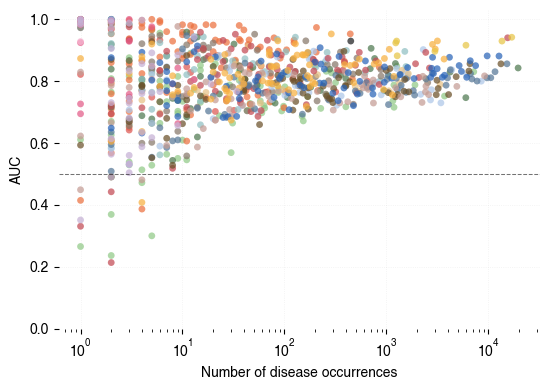

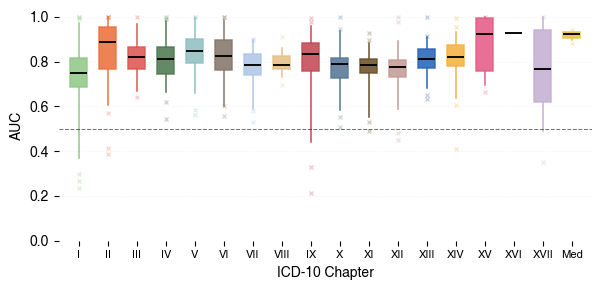

saved: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/auc_scatter_KR_full.pdf
saved: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/auc_boxplot_by_chapter_KR_full.pdf


In [59]:
df, cfg, chapter_order, chapter_palette, auc_col, occ_col = load_auc_dataset(DATASET)
print(f"[{DATASET}] rows={len(df):,} | tokens={df['token_id'].nunique():,} | AUC column={auc_col} | count column={occ_col}")
SAVE_FIGURES = True
scatter_path = OUTPUT_DIR / f"auc_scatter_{DATASET}.pdf" if SAVE_FIGURES else None
boxplot_path = OUTPUT_DIR / f"auc_boxplot_by_chapter_{DATASET}.pdf" if SAVE_FIGURES else None


fig_scatter = draw_auc_scatter(
    df, chapter_order, chapter_palette,
    title=f"AUC vs disease occurrences ({cfg['title']})",
    save_path=scatter_path,
    # show_chapter_legend=True,
)
plt.show()

fig_box = draw_chapter_auc_boxplot(
    df, chapter_order, chapter_palette,
    title=f"AUC by ICD-10 chapter ({cfg['title']})",
    save_path=boxplot_path,
    # show_chapter_legend=SHOW_CHAPTER_LEGEND,
)
plt.show()

if SAVE_FIGURES:
    print(f"saved: {scatter_path}")
    print(f"saved: {boxplot_path}")

[KR_full] rows=921 | tokens=921


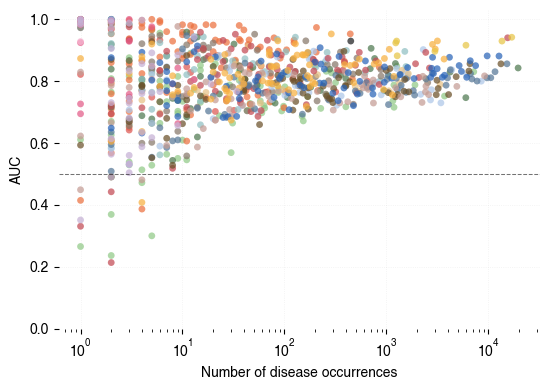

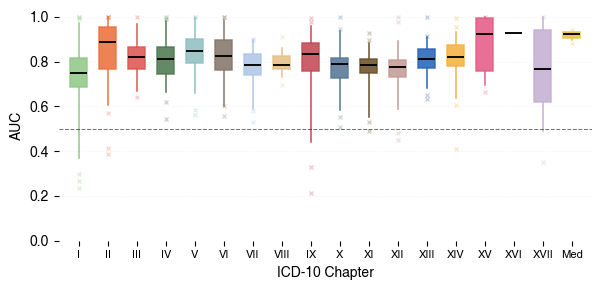

[JMDC] rows=961 | tokens=961


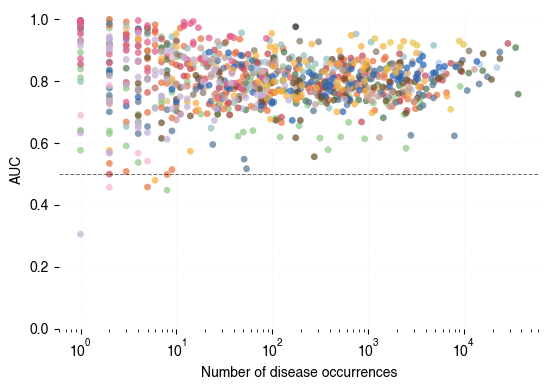

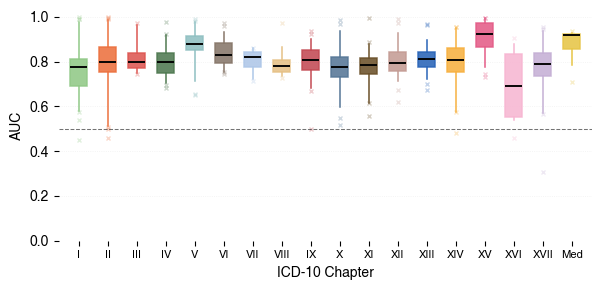

[UKB] rows=938 | tokens=938


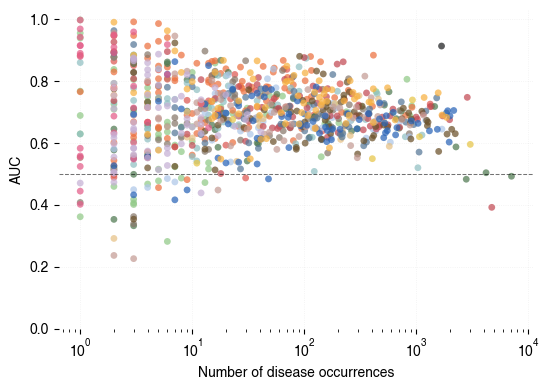

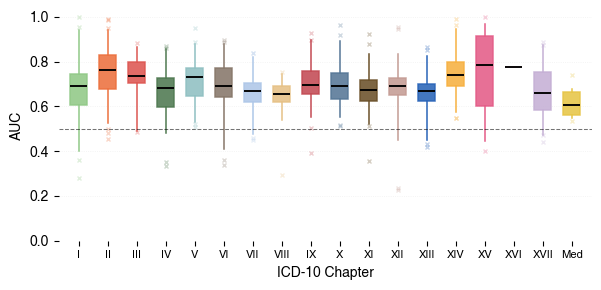

In [60]:
# Optional: regenerate the main datasets in one pass.
RUN_BATCH = True
BATCH_DATASETS = ['KR_full', 'JMDC', 'UKB']

if RUN_BATCH:
    for dataset in BATCH_DATASETS:
        df_, cfg_, chapter_order_, chapter_palette_, auc_col_, occ_col_ = load_auc_dataset(dataset)
        print(f"[{dataset}] rows={len(df_):,} | tokens={df_['token_id'].nunique():,}")

        fig = draw_auc_scatter(
            df_, chapter_order_, chapter_palette_,
            title=f"AUC vs disease occurrences ({cfg_['title']})",
            save_path=OUTPUT_DIR / f"auc_scatter_{dataset}.pdf",
            # show_chapter_legend=SHOW_CHAPTER_LEGEND,
        )
        plt.show()

        fig = draw_chapter_auc_boxplot(
            df_, chapter_order_, chapter_palette_,
            title=f"AUC by ICD-10 chapter ({cfg_['title']})",
            save_path=OUTPUT_DIR / f"auc_boxplot_by_chapter_{dataset}.pdf",
            # show_chapter_legend=SHOW_CHAPTER_LEGEND,
        )
        plt.show()

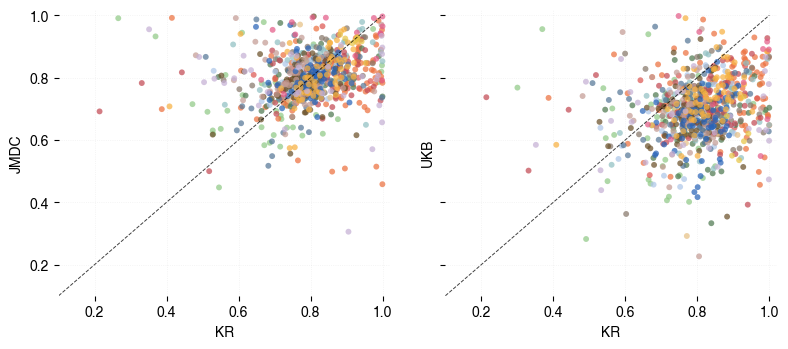

,comparison,n_tokens,mean_base_auc,mean_target_auc,pearson_r
0,KR vs JMDC,797,0.802208,0.800188,0.216957
1,KR vs UKB,817,0.803550,0.694788,0.196349


In [ ]:
def _paired_auc_table(base_dataset='KR_full', target_dataset='JMDC'):
    base_df, base_cfg, _, _, _, _ = load_auc_dataset(base_dataset)
    target_df, target_cfg, _, _, _, _ = load_auc_dataset(target_dataset)

    base = (
        base_df[['token_id', 'auc_value', 'chapter_code']]
        .drop_duplicates('token_id')
        .rename(columns={'auc_value': 'auc_base'})
    )
    target = (
        target_df[['token_id', 'auc_value']]
        .drop_duplicates('token_id')
        .rename(columns={'auc_value': 'auc_target'})
    )
    paired = base.merge(target, on='token_id', how='inner')
    paired['base_dataset'] = base_cfg['title']
    paired['target_dataset'] = target_cfg['title']
    return paired, base_cfg, target_cfg


def draw_cross_dataset_auc_scatter(base_dataset='KR_full', target_datasets=('JMDC', 'UKB'), save_path=None):
    _, _, chapter_order, chapter_palette, _, _ = load_auc_dataset(base_dataset)
    fig, axes = plt.subplots(1, len(target_datasets), figsize=(4.0 * len(target_datasets), 3.6), sharex=True, sharey=True)
    if len(target_datasets) == 1:
        axes = [axes]

    summary = []
    for ax, target_dataset in zip(axes, target_datasets):
        paired, base_cfg, target_cfg = _paired_auc_table(base_dataset, target_dataset)

        for chapter in chapter_order:
            sub = paired[paired['chapter_code'] == chapter]
            if sub.empty:
                continue
            ax.scatter(
                sub['auc_base'], sub['auc_target'],
                s=18, alpha=0.72,
                color=chapter_palette.get(chapter, '#999999'),
                edgecolors='none',
            )

        ax.plot([0.1, 1.0], [0.1, 1.0], color='black', linestyle='--', linewidth=0.7, alpha=0.75)
        ax.set_xlim(0.1, 1.02)
        ax.set_ylim(0.1, 1.02)
        ax.set_xlabel(base_cfg['title'])
        ax.set_ylabel(target_cfg['title'])
        ax.grid(True, which='major', alpha=0.18, linewidth=0.6)
        ax.grid(False, which='minor')

        corr = paired[['auc_base', 'auc_target']].corr().iloc[0, 1]
        summary.append({
            'comparison': f"{base_cfg['title']} vs {target_cfg['title']}",
            'n_tokens': len(paired),
            'mean_base_auc': paired['auc_base'].mean(),
            'mean_target_auc': paired['auc_target'].mean(),
            'pearson_r': corr,
        })

    fig.tight_layout(w_pad=2.0)
    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
    return fig, pd.DataFrame(summary)


fig_pair, pair_summary = draw_cross_dataset_auc_scatter(
    base_dataset='KR_full',
    target_datasets=('JMDC', 'UKB'),
    save_path=OUTPUT_DIR / 'auc_scatter_KR_vs_JMDC_UKB.pdf' if SAVE_FIGURES else None,
)
plt.show()
pair_summary

### CKB

CKB codebook groups with valid label tokens: 28
loaded cache: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/ckb_codebook_specs_roc_curves.npz


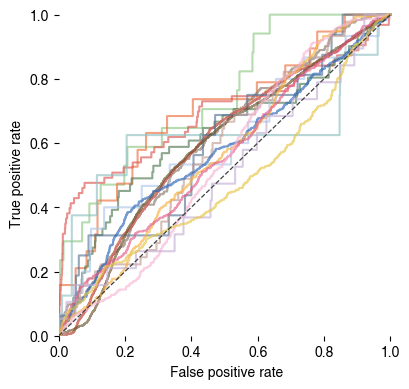

plotting 18 / 24 curves after occurrences > 10 filter


,codebook_id,name,icd10_codes,chapter_code,target_tokens,n_target_tokens,occurrences,missing_codes,auc_from_csv,auc_roc_pooled,n_pos_roc,n_neg_roc
0,16,Cirrhosis/Chronic hepatitis,"K70,K71,K72,K73,K74",XI,"693,694,695,696,697",5,68.0,NaN,0.634713,0.743987,17,23305
1,25,Neurasthenia,F48,V,325,1,62.0,NaN,0.725146,0.695033,19,23277
2,9,Asthma,"J45,J46",X,"612,613",2,242.0,NaN,0.682632,0.689555,63,23153
3,21,Rheumatoid arthritis,"M05,M06",XIII,"787,788",2,222.0,NaN,0.561450,0.623567,51,23153
4,3,Acute myocardial infarction,"I21,I22",IX,"514,515",2,44.0,NaN,0.575731,0.616619,8,23342
5,17,Gallstone/Gallbladder disease,"K80,K81,K82",XI,"701,702,703",3,932.0,NaN,0.619858,0.611958,245,22466
6,15,Osteoporosis,"M80,M81",XIII,"844,845",2,58.0,NaN,0.647320,0.600230,15,23314
7,32,Any cerebrovascular disease,"I60,I61,I62,I63,I64,I65,I66,I67,I68,I69,G45,G46",VI,"393,394,545,546,547,548,549,550,551,552,553,554",12,8648.0,NaN,0.505279,0.598124,2106,17188
8,8,Stroke or TIA,"I60,I61,I63,I64,G45",VI,"393,545,546,548,549",5,8648.0,NaN,0.503619,0.597199,2106,17188
9,4,Angina pectoris,I20,IX,513,1,86.0,NaN,0.624024,0.597103,16,23300


saved: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/auc_roc_curves_CKB.pdf


In [72]:
# CKB disease-level ROC curves (FPR / TPR).
# AUC summary CSVs store scalar AUC values only, so this cell recomputes per-disease
# y_true / y_score from the CKB binary data and checkpoint, then plots ROC curves.
import dataclasses
import io
import json
import sys

import torch
from sklearn.metrics import auc as sklearn_auc
from sklearn.metrics import roc_curve
from tqdm.auto import tqdm

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from evaluate_auc import CompositeDelphi, CompositeDelphiConfig, build_ckb_codebook_group_maps
from utils import get_batch_composite, get_p2i_composite

CKB_CKPT_PATH = REPO_DIR / 'out' / '0506' / 'ckpt.pt'
CKB_DATA_PATH = REPO_DIR.parent / 'data' / 'ckb_t2dm.bin'
CKB_RESULT_PATH = REPO_DIR / 'results' / '0506' / 'CKB_extval_rerun_current' / 'extval_ckb_df_both.csv'
CKB_SUBSET_SIZE = 10_000
CKB_SEED = 1337
CKB_BLOCK_SIZE = 512
CKB_NO_EVENT_TOKEN_RATE = 5
CKB_EVAL_BATCH_SIZE = 64
CKB_OFFSET_DAYS = 0.1
CKB_AGE_GROUPS = np.arange(40, 80, 5)
CKB_SCORE_MODE = 'logits'
CKB_SAVE_ROC_FIGURE = True
CKB_ROC_MIN_OCCURRENCES = 10
CKB_EXCLUDE_CODEBOOK_GROUP_IDS = {20}  # Exclude Malignant neoplasms (C00-C97)
CKB_ROC_CACHE = OUTPUT_DIR / 'ckb_codebook_specs_roc_curves.npz'
CKB_ROC_FIG_PATH = OUTPUT_DIR / 'auc_roc_curves_CKB.pdf' if CKB_SAVE_ROC_FIGURE else None
CKB_ROC_COLORS = [
    '#91c987', '#ec713f', '#dd5752', '#4f7951', '#90c0c2', '#87776a',
    '#aec7e8', '#e6c186', '#c34a54', '#567797', '#6b512a', '#c49c94',
    '#2964b8', '#f7b141', '#e45c88', '#f7b6d2', '#c5b0d5', '#E7C547',
    '#1d1f20',
]


def _load_ckb_model(ckpt_path, device):
    checkpoint = torch.load(ckpt_path, map_location=device)
    model_args = dict(checkpoint['model_args'])
    valid_fields = {f.name for f in dataclasses.fields(CompositeDelphiConfig)}
    conf = CompositeDelphiConfig(**{k: v for k, v in model_args.items() if k in valid_fields})
    model = CompositeDelphi(conf)
    state_dict = {
        k.replace('module.', '').replace('_orig_mod.', ''): v
        for k, v in checkpoint['model'].items()
    }
    model.load_state_dict(state_dict)
    model.eval().to(device)
    return model, model_args, checkpoint


def _load_ckb_batch(data_path, model_args, device_for_batch='cpu'):
    composite_dtype = np.dtype([
        ('ID', np.uint32),
        ('AGE', np.uint32),
        ('DATA', np.uint32),
        ('SHIFT', np.uint32),
        ('TOTAL', np.uint32),
    ])
    data = np.fromfile(data_path, dtype=composite_dtype)
    p2i = get_p2i_composite(data)
    subset_size = len(p2i) if CKB_SUBSET_SIZE == -1 else min(CKB_SUBSET_SIZE, len(p2i))
    np.random.seed(CKB_SEED)
    patient_indices = np.random.choice(len(p2i), size=subset_size, replace=False)
    patient_indices = sorted(patient_indices.tolist())
    batch = get_batch_composite(
        patient_indices,
        data,
        p2i,
        select='left',
        block_size=CKB_BLOCK_SIZE,
        device=device_for_batch,
        padding='random',
        no_event_token_rate=CKB_NO_EVENT_TOKEN_RATE,
        apply_token_shift=bool(model_args.get('apply_token_shift', False)),
        separate_shift_na_from_padding=bool(model_args.get('separate_shift_na_from_padding', False)),
        shift_na_raw_token=int(model_args.get('shift_na_raw_token', 4)),
    )
    return batch, subset_size, len(p2i)


def _parse_token_set(value):
    if pd.isna(value):
        return []
    return [int(tok) for tok in str(value).split(',') if str(tok).strip()]


def _load_ckb_codebook_summary():
    labels = pd.read_csv(REPO_DIR.parent / 'data' / 'labels.csv', header=None, usecols=[0], names=['name'])
    labels['index'] = range(len(labels))
    token_sets, label_map, icd_code_map, missing_code_map = build_ckb_codebook_group_maps(
        labels,
        token_offset=0,
        vocab_size=1289,
    )
    for group_id in {int(gid) for gid in CKB_EXCLUDE_CODEBOOK_GROUP_IDS}:
        token_sets.pop(group_id, None)
        label_map.pop(group_id, None)
        icd_code_map.pop(group_id, None)
        missing_code_map.pop(group_id, None)

    auc_lookup = {}
    n_lookup = {}
    if CKB_RESULT_PATH.exists():
        result_df = pd.read_csv(CKB_RESULT_PATH)
        if 'status' in result_df.columns:
            result_df = result_df[result_df['status'].eq('ok')].copy()
        result_df['codebook_id'] = result_df.get('ckb_codebook_id', result_df['token']).astype(int)
        auc_lookup = result_df.set_index('codebook_id')['auc'].to_dict()
        n_lookup = result_df.set_index('codebook_id')['n_diseased'].to_dict()

    rows = []
    for group_id in sorted(token_sets):
        rows.append({
            'codebook_id': int(group_id),
            'name': label_map.get(int(group_id), f'CKB group {group_id}'),
            'icd10_codes': icd_code_map.get(int(group_id), ''),
            'target_tokens_list': token_sets[int(group_id)],
            'n_target_tokens': len(token_sets[int(group_id)]),
            'auc_value': float(auc_lookup[group_id]) if group_id in auc_lookup else np.nan,
            'occurrences': int(n_lookup[group_id]) if group_id in n_lookup and pd.notna(n_lookup[group_id]) else np.nan,
            'missing_codes': ','.join(map(str, missing_code_map.get(int(group_id), []))),
        })
    df = pd.DataFrame(rows)

    meta, _, chapter_palette = load_chapter_metadata()
    token_to_chapter = meta.set_index('token_id')['chapter_code'].to_dict()
    token_to_color = meta.set_index('token_id')['color'].to_dict()
    df['chapter_code'] = df['target_tokens_list'].map(lambda toks: token_to_chapter.get(toks[0], 'CKB'))
    df['color'] = df['target_tokens_list'].map(lambda toks: token_to_color.get(toks[0], '#777777'))
    df = df.sort_values('auc_value', ascending=False, na_position='last').reset_index(drop=True)
    print(f'CKB codebook groups with valid label tokens: {len(df)}')
    return df, chapter_palette


def _score_codebook_groups(model, batch, token_sets, device):
    x_data, x_shift, x_total, x_ages = batch[0], batch[1], batch[2], batch[3]
    unique_tokens = sorted({int(tok) for toks in token_sets for tok in toks})
    token_pos = {tok: i for i, tok in enumerate(unique_tokens)}
    scores = []
    num_batches = (x_data.shape[0] + CKB_EVAL_BATCH_SIZE - 1) // CKB_EVAL_BATCH_SIZE
    with torch.no_grad():
        for start in tqdm(range(0, x_data.shape[0], CKB_EVAL_BATCH_SIZE), total=num_batches, desc='CKB model inference'):
            end = min(start + CKB_EVAL_BATCH_SIZE, x_data.shape[0])
            outputs = model(
                x_data[start:end].to(device),
                x_shift[start:end].to(device),
                x_total[start:end].to(device),
                x_ages[start:end].to(device),
                return_attention=False,
            )[0]
            data_logits = outputs['data']
            if CKB_SCORE_MODE == 'logits':
                token_scores = data_logits[:, :, unique_tokens]
            elif CKB_SCORE_MODE == 'data_prob':
                token_scores = torch.softmax(data_logits, dim=-1)[:, :, unique_tokens]
            else:
                raise ValueError(f'Unsupported CKB_SCORE_MODE={CKB_SCORE_MODE!r}')

            group_scores = []
            for toks in token_sets:
                idx = [token_pos[int(tok)] for tok in toks if int(tok) in token_pos]
                selected = token_scores[:, :, idx]
                if selected.shape[-1] == 1:
                    group_scores.append(selected[:, :, 0])
                elif CKB_SCORE_MODE == 'logits':
                    group_scores.append(selected.max(dim=-1).values)
                else:
                    group_scores.append(selected.sum(dim=-1))
            scores.append(torch.stack(group_scores, dim=-1).detach().cpu().numpy().astype('float32'))
    return np.vstack(scores)


def _pooled_roc_for_codebook_group(d_np, pred_idx_precompute, score_tensor, group_idx, group_id, target_tokens, age_groups):
    target_tokens = np.asarray([int(tok) for tok in target_tokens], dtype=d_np['target_data'].dtype)
    case_mask = np.isin(d_np['target_data'], target_tokens)
    wk = np.where(case_mask)
    patient_has_disease = case_mask.any(axis=1)
    wc = np.where((~case_mask) & (~patient_has_disease[:, None]))
    if len(wk[0]) < 2 or len(wc[0]) == 0:
        return None

    wall0 = np.concatenate([wk[0], wc[0]])
    wall1 = np.concatenate([wk[1], wc[1]])
    labels = np.concatenate([
        np.ones(len(wk[0]), dtype=np.int8),
        np.zeros(len(wc[0]), dtype=np.int8),
    ])
    pred_idx = pred_idx_precompute[(wall0, wall1)]
    valid = pred_idx != -1
    if not valid.any():
        return None

    wall0 = wall0[valid]
    pred_idx = pred_idx[valid]
    labels = labels[valid]
    scores = score_tensor[..., group_idx][(wall0, pred_idx)]
    pred_age_years = d_np['ages'][(wall0, pred_idx)] / 365.25

    age_step = age_groups[1] - age_groups[0]
    selected_all = np.zeros(len(scores), dtype=bool)
    rng = np.random.default_rng(CKB_SEED + int(group_id))
    for aa in age_groups:
        in_bin = (pred_age_years >= aa) & (pred_age_years < aa + age_step)
        selected_patients = wall0[in_bin]
        if len(selected_patients) == 0:
            continue
        perm = rng.permutation(len(selected_patients))
        _, unique_pos = np.unique(selected_patients[perm], return_index=True)
        selected_local = perm[unique_pos]
        selected_global = np.where(in_bin)[0][selected_local]
        selected_all[selected_global] = True

    y_true = labels[selected_all]
    y_score = scores[selected_all]
    if len(np.unique(y_true)) < 2:
        return None

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    return {
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'auc': float(sklearn_auc(fpr, tpr)),
        'n_pos': int(y_true.sum()),
        'n_neg': int((y_true == 0).sum()),
    }


def compute_ckb_roc_curves():
    ckb_df, chapter_palette = _load_ckb_codebook_summary()
    group_ids = ckb_df['codebook_id'].astype(int).tolist()
    target_token_sets = ckb_df['target_tokens_list'].tolist()

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Using device={device}')
    model, model_args, checkpoint = _load_ckb_model(CKB_CKPT_PATH, device)
    batch, subset_size, total_patients = _load_ckb_batch(CKB_DATA_PATH, model_args, device_for_batch='cpu')
    print(f'CKB patients: using {subset_size:,} / {total_patients:,}')

    d_np = {
        'data_tokens': batch[0].cpu().numpy(),
        'ages': batch[3].cpu().numpy(),
        'target_data': batch[4].cpu().numpy(),
        'target_ages': batch[7].cpu().numpy(),
    }
    pred_idx_precompute = (
        d_np['ages'][:, :, np.newaxis] <= d_np['target_ages'][:, np.newaxis, :] - CKB_OFFSET_DAYS
    ).sum(1) - 1

    score_tensor = _score_codebook_groups(model, batch, target_token_sets, device)
    curves = {}
    summary_rows = []
    for j, row in tqdm(list(ckb_df.iterrows()), desc='Computing ROC curves'):
        group_id = int(row['codebook_id'])
        target_tokens = row['target_tokens_list']
        curve = _pooled_roc_for_codebook_group(
            d_np, pred_idx_precompute, score_tensor, j, group_id, target_tokens, CKB_AGE_GROUPS
        )
        if curve is None:
            continue
        key = str(group_id)
        curves[key] = {
            'fpr': curve['fpr'].tolist(),
            'tpr': curve['tpr'].tolist(),
            'thresholds': curve['thresholds'].tolist(),
            'auc': curve['auc'],
            'n_pos': curve['n_pos'],
            'n_neg': curve['n_neg'],
        }
        summary_rows.append({
            'codebook_id': group_id,
            'name': row['name'],
            'icd10_codes': row.get('icd10_codes', ''),
            'chapter_code': row['chapter_code'],
            'target_tokens': ','.join(map(str, target_tokens)),
            'n_target_tokens': len(target_tokens),
            'occurrences': int(row['occurrences']) if pd.notna(row['occurrences']) else np.nan,
            'missing_codes': row.get('missing_codes', ''),
            'auc_from_csv': float(row['auc_value']) if pd.notna(row['auc_value']) else np.nan,
            'auc_roc_pooled': curve['auc'],
            'n_pos_roc': curve['n_pos'],
            'n_neg_roc': curve['n_neg'],
        })

    summary = pd.DataFrame(summary_rows).sort_values('auc_roc_pooled', ascending=False)
    np.savez_compressed(
        CKB_ROC_CACHE,
        curves_json=np.array(json.dumps(curves)),
        summary_csv=np.array(summary.to_csv(index=False)),
    )
    print(f'saved cache: {CKB_ROC_CACHE}')
    return curves, summary, chapter_palette


def load_ckb_roc_cache():
    _, chapter_palette = _load_ckb_codebook_summary()
    with np.load(CKB_ROC_CACHE, allow_pickle=False) as z:
        curves = json.loads(str(z['curves_json']))
        summary = pd.read_csv(io.StringIO(str(z['summary_csv'])))

    excluded_ids = {int(gid) for gid in CKB_EXCLUDE_CODEBOOK_GROUP_IDS}
    if excluded_ids and 'codebook_id' in summary.columns:
        summary = summary.loc[~summary['codebook_id'].astype(int).isin(excluded_ids)].copy()
        for gid in excluded_ids:
            curves.pop(str(gid), None)
    return curves, summary, chapter_palette


def _short_label(text, max_len=34):
    text = str(text)
    return text if len(text) <= max_len else text[:max_len - 3] + '...'


def _filter_ckb_roc_summary(summary, min_occurrences=CKB_ROC_MIN_OCCURRENCES):
    for candidate in ('occurrences', 'n_diseased', 'n_pos_roc'):
        if candidate in summary.columns:
            occ_col = candidate
            break
    else:
        raise ValueError('summary must contain occurrences, n_diseased, or n_pos_roc')
    plot_df = summary.copy()
    plot_df[occ_col] = pd.to_numeric(plot_df[occ_col], errors='coerce')
    plot_df = plot_df.loc[plot_df[occ_col] > min_occurrences].copy()
    return plot_df.sort_values('auc_roc_pooled', ascending=False).reset_index(drop=True), occ_col


def plot_ckb_roc_overlay(
    curves, summary, chapter_palette=None, save_path=None,
    min_occurrences=CKB_ROC_MIN_OCCURRENCES,
    show_legend=False,
    legend_loc='center left',
    legend_bbox_to_anchor=(1.02, 0.5),
    legend_ncol=1,
    legend_fontsize=8,
):
    plot_df, occ_col = _filter_ckb_roc_summary(summary, min_occurrences=min_occurrences)
    if plot_df.empty:
        raise ValueError(f'No ROC curves remain after filtering {occ_col} > {min_occurrences}.')

    fig, ax = plt.subplots(figsize=(4.2, 4.0))
    for i, (_, row) in enumerate(plot_df.iterrows()):
        key = str(int(row['codebook_id']))
        curve = curves[key]
        label = f"{_short_label(row['name'], 34)} (AUC={row['auc_roc_pooled']:.3f})"
        color = CKB_ROC_COLORS[i % len(CKB_ROC_COLORS)]
        ax.plot(curve['fpr'], curve['tpr'], color=color, linewidth=1.5, alpha=0.65, label=label)

    ax.plot([0, 1], [0, 1], color='0.25', linestyle='--', linewidth=0.9)
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    # ax.set_title(f'CKB disease-level ROC curves ({occ_col} > {min_occurrences})')
    ax.grid(False)
    if show_legend:
        ax.legend(
            loc=legend_loc,
            bbox_to_anchor=legend_bbox_to_anchor,
            ncol=legend_ncol,
            frameon=False,
            fontsize=legend_fontsize,
            handlelength=1.6,
            handletextpad=0.45,
            columnspacing=1.0,
            labelspacing=0.45,
        )
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
    return fig


if CKB_ROC_CACHE.exists():
    ckb_roc_curves, ckb_roc_summary, ckb_chapter_palette = load_ckb_roc_cache()
    print(f'loaded cache: {CKB_ROC_CACHE}')
else:
    ckb_roc_curves, ckb_roc_summary, ckb_chapter_palette = compute_ckb_roc_curves()

fig = plot_ckb_roc_overlay(
    ckb_roc_curves,
    ckb_roc_summary,
    ckb_chapter_palette,
    save_path=CKB_ROC_FIG_PATH,
)
plt.show()

ckb_roc_plot_summary, ckb_roc_occ_col = _filter_ckb_roc_summary(ckb_roc_summary)
print(f'plotting {len(ckb_roc_plot_summary)} / {len(ckb_roc_summary)} curves after {ckb_roc_occ_col} > {CKB_ROC_MIN_OCCURRENCES} filter')
display(ckb_roc_plot_summary)
if CKB_ROC_FIG_PATH is not None:
    print(f'saved: {CKB_ROC_FIG_PATH}')